# GPT1 구현

## Transformer 대비 변경 사항

<p align="center">
<img src="./img/trs_to_gpt1.png" width="50%" height="20%">
</p>

1. 디코더만 사용 (Encoder-Decoder cross attention 제거)  
디코더 구조만 사용하므로, 디코더에서 Encoder-Decoder cross attention 모듈을 제거한다.

2. Positional embedding 사용  
토큰(단어)의 위치 정보를 학습을 통해 구해서 사용함

- 변경 사항 코드에서 주석으로도 달기

- QA데이터로 pre-train하는 거면 데이터를 어떻게 넣을 것인가(어떤 출력물을 만들어 낼 것인가)  
&rarr; Q 문장과 A문장을 결합해서 하나의 말뭉치로 학습함. 이때 두 문장 사이에 '\n'을 넣고 붙여서 모델에게 구분하는 것을 알려줌  
&rarr; 하나의 text로 묶어서 next token을 생성하는 pre-train 모델을 만든 것이므로, 상담에 관련된 글의 맥락이나 문법을 토대로 출력(토큰)을 만들 것으로 예상함  

- 문제: 심리상담 데이터로 학습하고, 챗봇처럼 쓴다 (들어있지 않은 정보로 학습한 거에 그렇게 물어보면 횡설수설한다.)
- 우리가 주어진 조건에서 어떤 걸 만들려고 하나, 만들었으면 어떻게 써야 하는지 고민하자.  
&rarr; 특정 도메인에 맞는 질문과 응답을 기대해야 할 것 같다.

- 모델이 똑같은 토큰을 내뱉으면 뭘 생각해야 하나.  
&rarr; beam search, temperature, top-k sampling 같은 기법들이 있다고 함.  
&rarr; 하나의 출력 내에서 같은 토큰을 반복하지는 않고, 서로 다른 input에 대해 같은 문장 출력을 내뱉어서 temperature와 multinomial을 적용해보았음

# 0. 라이브러리 import 및 셋팅

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, TensorDataset, DataLoader
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
from torchinfo import summary

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import re
from bs4 import BeautifulSoup
import sentencepiece as spm
from collections import Counter

import math
import os
import urllib.request
import zipfile
import random

In [2]:
# 재현성 확보를 위한 시드 고정 함수
def set_seed(seed=42):
    # 1. 파이썬 기본 난수 생성기 고정
    random.seed(seed)
    # 2. 넘파이 고정
    np.random.seed(seed)
    # 3. 파이토치 CPU 시드 고정
    torch.manual_seed(seed)
    # 4. 파이토치 GPU 시드 고정 (멀티 GPU 포함)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    # 5. Cudnn(GPU 연산 라이브러리)의 결정론적 연산 설정
    # 연산 속도는 약간 느려질 수 있지만, 결과는 동일하게 나옴
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # 6. 환경 변수 고정 (HuggingFace 등 일부 라이브러리 대응)
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    print(f"Seed fixed to: {seed}")

# 실행
set_seed(42)

Seed fixed to: 42


In [3]:
DATA_PATH = "./data/"
MODEL_PATH = "./models/"

# 1. 데이터 전처리

## 1.1. 데이터 불러오기

In [4]:
DATA_NAME = "ChatbotData.csv"

In [5]:
raw_data = pd.read_csv(DATA_PATH + DATA_NAME)

print("Data Size:", len(raw_data))
raw_data.head()

Data Size: 11823


,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0


## 1.2. 데이터 분석 및 전처리

- next token prediction을 위한 pre-train 모델을 만들기 위해, Q와 A를 합쳐 하나의 문장으로 만들어서 학습  
- Q 문장과 A 문장을 이어 붙이되, 별도 문장임을 표현하기 위해 '\n' 토큰을 두 문장 사이에 추가할 것임


### 1.2.1. 중복 샘플 확인

In [6]:
print("전체 샘플 수: ", len(raw_data))
print('Q열에서 중복을 배제한 유일한 샘플의 수 :', raw_data['Q'].nunique())
print('A열에서 중복을 배제한 유일한 샘플의 수 :', raw_data['A'].nunique())

전체 샘플 수:  11823
Q열에서 중복을 배제한 유일한 샘플의 수 : 11662
A열에서 중복을 배제한 유일한 샘플의 수 : 7779


In [7]:
print("Q, A 둘다 중복인 데이터: ", raw_data.duplicated(subset=['Q', 'A'], keep=False).sum())
raw_data[raw_data.duplicated(subset=['Q', 'A'], keep=False)].sort_values(by='Q').head(6)

Q, A 둘다 중복인 데이터:  146


,Q,A,label
152,결혼이나 하지 왜 자꾸 나한테 화 내냐구!,힘들겠네요.,0
5527,결혼이나 하지 왜 자꾸 나한테 화 내냐구!,힘들겠네요.,1
5537,고백하고 후회하면 어떡하지,후회는 후회를 낳을뿐이에요. 용기 내세요.,1
189,고백하고 후회하면 어떡하지,후회는 후회를 낳을뿐이에요. 용기 내세요.,0
226,공부는 내 체질이 아닌 것 같아,확신이 없나봐요.,0
5542,공부는 내 체질이 아닌 것 같아,확신이 없나봐요.,1


In [8]:
raw_data.drop_duplicates(subset=['Q', 'A'], inplace=True)
print('전체 샘플수 :', (len(raw_data)))

전체 샘플수 : 11750


&rarr; Q와 A를 이어 붙일 것이므로 Q,A 모두 중복인 경우가 있다면 제거

### 1.2.2. 결측치 확인

In [9]:
print(raw_data.isnull().sum())

Q        0
A        0
label    0
dtype: int64


In [10]:
# 결측치 있으면 제거
# raw_data.dropna(axis=0, inplace=True)
# print('전체 샘플수 :', (len(raw_data)))

&rarr; 결측치 없음

### 1.2.3. 전처리

In [11]:
# 데이터 전처리 함수
def preprocess_sentence(sentence):
    # 1. HTML 태그 제거 (BeautifulSoup 활용)
    sentence = BeautifulSoup(sentence, "lxml").text
    
    # 2. 괄호로 둘러싸인 문자열 제거 (부가 설명 제거)
    sentence = re.sub(r'\([^)]*\)', '', sentence)
    
    # 3. 특수문자 제거 (한글, 영어, 숫자, ?, !만 남기기)    
    sentence = re.sub(r"[^가-힣a-zA-Z0-9\s?!.]", " ", sentence) 
    
    # 4. 의미 없는 자음/모음 반복 줄이기 (ㅋㅋㅋㅋㅋ -> ㅋㅋ)    
    sentence = re.sub(r'([ㄱ-ㅎㅏ-ㅣ])\1+', r'\1\1', sentence)
    
    # 5. 공백 정규화 (연속된 공백 하나로)
    sentence = re.sub(r'\s+', ' ', sentence).strip()    

    return sentence

In [12]:
# 전처리 후 별도 관리
preprocessed_df = pd.DataFrame()

preprocessed_df['Q'] = raw_data['Q'].apply(preprocess_sentence)
preprocessed_df['A'] = raw_data['A'].apply(preprocess_sentence)

print(len(preprocessed_df))

11750


In [13]:
# 중복 샘플 재확인
preprocessed_df.duplicated(subset=['Q', 'A'], keep=False).sum()


2

In [14]:
# 중복 샘플 제거
preprocessed_df.drop_duplicates(subset=['Q', 'A'], inplace=True)
print(len(preprocessed_df))


11749


In [15]:
# 전처리 후 결측치 재확인
print(preprocessed_df.isnull().sum())

Q    0
A    0
dtype: int64


### 1.2.4. 문장 합치기

In [16]:
# Q 문장과 A문장을 합치는 함수
def merge_sentences(text_df):
    q = text_df['Q']
    a = text_df['A']
    
    # 두 문장 사이에 '\n' 개행을 넣고 붙여줌
    return f"{q}\n{a}"

In [17]:
preprocessed_df['text'] = preprocessed_df.apply(merge_sentences, axis=1)
preprocessed_df.head()

,Q,A,text
0,12시 땡!,하루가 또 가네요.,12시 땡!\n하루가 또 가네요.
1,1지망 학교 떨어졌어,위로해 드립니다.,1지망 학교 떨어졌어\n위로해 드립니다.
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,3박4일 놀러가고 싶다\n여행은 언제나 좋죠.
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,3박4일 정도 놀러가고 싶다\n여행은 언제나 좋죠.
4,PPL 심하네,눈살이 찌푸려지죠.,PPL 심하네\n눈살이 찌푸려지죠.


In [18]:
# '\n' 적용 잘 됐는지 출력해서 확인
print(preprocessed_df['text'].iloc[0])

12시 땡!
하루가 또 가네요.


### 1.2.5. 문장 통계 확인

In [19]:
# corpus를 구성하는 각 문장의 길이를 재고, 
def check_sentence_stats(corpus):
   
    len_sentence = [len(sentence) for sentence in corpus]
    len_sentence = np.array(len_sentence)

    print('문장 길이 평균: ', np.mean(len_sentence))
    print('문장 길이 최대: ', np.max(len_sentence))
    print('문장 길이 최소: ', np.min(len_sentence))
    print('문장 길이 표준편차: ', np.std(len_sentence))
    print('문장 길이 중위수: ', np.median(len_sentence))

    max_len_sentence = np.max(len_sentence)

    sentence_length = np.zeros((max_len_sentence), dtype=int)

    for sen in corpus:
        sentence_length[len(sen)-1] += 1

    plt.bar(range(max_len_sentence), sentence_length, width=1.0)
    plt.title("Sentence Length Distribution")
    plt.show()

    return sentence_length

In [20]:
# 문장들을 주면 해당하는 길이의 문장을 출력하는 함수
def check_sentence_with_length(raw, length):
    count = 0

    for i, sen in enumerate(raw):
        if len(sen) == length:
            print(i, sen)
            count += 1
            if count > 100: return

In [21]:
# 문장 길이 최소: 1인 경우 확인 -> 합쳤으니까 1인 경우는 없음
check_sentence_with_length(preprocessed_df['text'], 1)

In [22]:
# 문장 길이 최소: 3인 경우 확인 (Q의 문장 길이 1, A의 문장 길이:1)
check_sentence_with_length(preprocessed_df['text'], 3)

2995 야
네
3620 음
음
3621 응
네


&rarr; Q와 A의 문장 길이가 1이어도 대응이 잘 되고 빈도도 적으므로 그대로 사용

문장 길이 평균:  28.88016001361818
문장 길이 최대:  91
문장 길이 최소:  3
문장 길이 표준편차:  10.089434380896115
문장 길이 중위수:  27.0


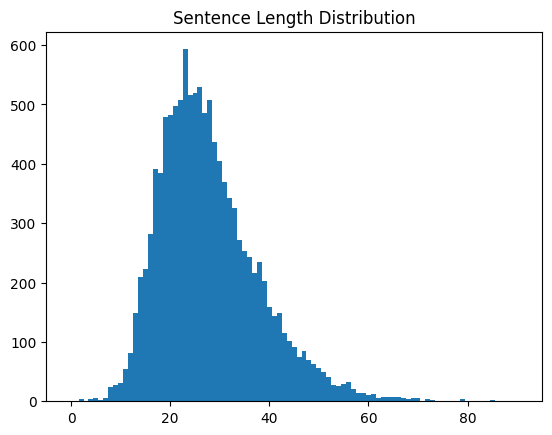

In [23]:
sentence_length = check_sentence_stats(preprocessed_df['text'])

&rarr; 평균과 중위수가 인접해서 치우친 데이터도 아니고, 데이터 개수(11749개)가 적다고 판단하여 모든 데이터를 최대 길이 문장까지 사용하기로 함

In [24]:
# 여기서의 MAX_SEN_LEN은 토크나이저 학습을 위한 최대 문장 길이를 의미함
# 현재 데이터로만 SentencePiece를 학습할 것이기 때문에 100으로 잡아줌

MAX_SEN_LEN = 100

## 1.3. SentencePiece 학습

### 1.3.1. SentencePiece 필요성 확인

In [42]:
# 등장 빈도수 낮은 단어를 어휘 사전에서 제외하기 위해 통계량 확인하는 함수
def check_rare_words_proportion(corpus, threshold):
    data_name = corpus.name
    corpus = corpus.tolist()
    # 단어 빈도수 계산
    word_counter = Counter()
    for text in corpus:
        word_counter.update(text.split())

    total_cnt = len(word_counter)  # 전체 단어 개수
    total_freq = sum(word_counter.values())  # 전체 단어 등장 횟수
    rare_cnt = sum(1 for count in word_counter.values() if count < threshold)  # 희귀 단어 개수
    rare_freq = sum(count for count in word_counter.values() if count < threshold)  # 희귀 단어 등장 횟수

    print("데이터: ", data_name)
    print('단어 집합(vocabulary)의 크기 :', total_cnt)
    print('등장 빈도가 %s번 이하인 희귀 단어의 수: %s'%(threshold - 1, rare_cnt))
    print('단어 집합에서 희귀 단어를 제외시킬 경우의 단어 집합의 크기 %s'%(total_cnt - rare_cnt))
    print("단어 집합에서 희귀 단어의 비율:", (rare_cnt / total_cnt)*100)
    print("전체 등장 빈도에서 희귀 단어 등장 빈도 비율:", (rare_freq / total_freq)*100)


In [47]:
check_rare_words_proportion(preprocessed_df['text'], 5)

데이터:  text
단어 집합(vocabulary)의 크기 : 21713
등장 빈도가 4번 이하인 희귀 단어의 수: 18817
단어 집합에서 희귀 단어를 제외시킬 경우의 단어 집합의 크기 2896
단어 집합에서 희귀 단어의 비율: 86.66236816653617
전체 등장 빈도에서 희귀 단어 등장 빈도 비율: 33.66251007982049


&rarr; 한국어에는 어절 단위의 희귀 단어를 제외하는 것이 적절하지 않음을 확인  
&rarr; vocab_size를 줄이려고 굳이 제외시킬 필요가 없음

### 1.3.2. SentencePiece 학습

In [59]:
# 많이 쓰이는 값
VOCAB_SIZE = 8000

In [51]:
# Q와 A를 모두 합친 데이터를 사용
all_text = preprocessed_df['text'].tolist()

In [52]:
# 파일로 저장 (SentencePiece는 파일 입력을 선호한다고 함)
with open(DATA_PATH + 'corpus_for_spm.txt', 'w', encoding='utf-8') as f:
    for line in all_text:
        f.write(line + '\n')

In [53]:
# SentencePiece 학습
spm.SentencePieceTrainer.train(
    input=DATA_PATH + 'corpus_for_spm.txt', 
    model_prefix=MODEL_PATH + 'chatbot_spm', 
    vocab_size=VOCAB_SIZE, # 8000
    model_type='bpe',     # 혹은 'unigram'
    max_sentence_length=MAX_SEN_LEN,
    pad_id=0,             # 특수 토큰 지정
    unk_id=1,
    bos_id=2,
    eos_id=3
)

sentencepiece_trainer.cc(77) LOG(INFO) Starts training with : 
trainer_spec {
  input: ./data/corpus_for_spm.txt
  input_format: 
  model_prefix: ./models/chatbot_spm
  model_type: BPE
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 100
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 1
  bos_id: 2
  eos_id: 3
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
  differential_privacy_noise_level: 0
  differe

- 토크나이저 결과 확인

In [25]:
# 모델 로드
sp_tokenizer = spm.SentencePieceProcessor()
sp_tokenizer.load(MODEL_PATH + 'chatbot_spm.model')

# 샘플 테스트
test_sentence = "사소한 일부터 시작해보세요 작은 곳에서 느끼는 행복은 생각보다 커요"
print("Tokenized:", sp_tokenizer.encode_as_pieces(test_sentence))

encoded = sp_tokenizer.encode(test_sentence, out_type=int)
# print("Encoded:", sp_tokenizer.encode_as_ids(test_sentence))
print("Encoded:", encoded)

decoded = sp_tokenizer.decode(encoded)
print("Decoded:", decoded)

Tokenized: ['▁사소한', '▁일부터', '▁시작해보세요', '▁작은', '▁곳에서', '▁느끼는', '▁행복은', '▁생각보다', '▁커', '요']
Encoded: [2786, 3792, 1919, 1354, 2760, 3353, 3076, 970, 422, 6927]
Decoded: 사소한 일부터 시작해보세요 작은 곳에서 느끼는 행복은 생각보다 커요


In [26]:
# 특수 토큰과 vocab_size 확인
print(f"PAD ID: {sp_tokenizer.pad_id()}") # 0
print(f"UNK ID: {sp_tokenizer.unk_id()}") # 1
print(f"BOS ID: {sp_tokenizer.bos_id()}") # 2
print(f"EOS ID: {sp_tokenizer.eos_id()}") # 3
print(f"Vocab Size: {len(sp_tokenizer)}")

PAD ID: 0
UNK ID: 1
BOS ID: 2
EOS ID: 3
Vocab Size: 8000


### 1.3.3. 최대 토큰 개수 결정

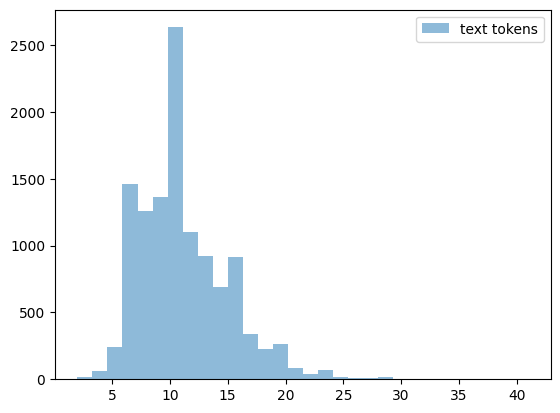

토큰 개수 최댓값: 41.0
토큰 개수 최댓값 빈도: 1
토큰 개수 최솟값: 2.0
토큰 개수 최솟값 빈도: 4
토큰 개수 평균: 11.156098365783691
토큰 개수 중앙값: 11.0


In [27]:
# 전체 데이터 인코딩 후 길이 측정
text_token_lens = [len(sp_tokenizer.encode_as_ids(sentence)) for sentence in preprocessed_df['text']]

plt.hist(text_token_lens, bins=30, alpha=0.5, label='text tokens')
plt.legend()
plt.show()

text_token_lens_tensor = torch.tensor(text_token_lens, dtype=torch.float)
print(f"토큰 개수 최댓값: {text_token_lens_tensor.max()}")
print(f"토큰 개수 최댓값 빈도: {(text_token_lens_tensor == text_token_lens_tensor.max()).sum()}")
print(f"토큰 개수 최솟값: {text_token_lens_tensor.min()}")
print(f"토큰 개수 최솟값 빈도: {(text_token_lens_tensor == text_token_lens_tensor.min()).sum()}")
print(f"토큰 개수 평균: {text_token_lens_tensor.mean()}")
print(f"토큰 개수 중앙값: {text_token_lens_tensor.median()}")


In [28]:
# BOS, EOS 토큰 고려하면 최소 43 이상 지정해야 함
# inference 단계에서 더 긴 글이 들어올 수 있으므로 넉넉하게 3배 정도인 128 지정

MAX_TOKEN_LEN = 128

## 1.4. 모델 학습을 위한 데이터셋 준비

### 1.4.1. 토큰화 및 정수 인덱싱

In [29]:
print(f"ID 0: {sp_tokenizer.IdToPiece(0)}")
print(f"ID 1: {sp_tokenizer.IdToPiece(1)}")
print(f"ID 2: {sp_tokenizer.IdToPiece(2)}")
print(f"ID 3: {sp_tokenizer.IdToPiece(3)}")

ID 0: <pad>
ID 1: <unk>
ID 2: <s>
ID 3: </s>


In [30]:
# 토큰화 및 정수 인덱싱
def tokenize_and_pad(sentences, tokenizer, max_token_len, mode=None):
    output = []
    for s in sentences:
        # 1. 순수 텍스트만 토큰화
        tokens = tokenizer.encode_as_ids(s)
        
        # 2. 모드에 따라 <s>, </s> 직접 삽입
        if mode == 'dec_input':
            tokens = [tokenizer.bos_id()] + tokens      # 반드시 2로 시작
        elif mode == 'dec_target':
            tokens = tokens + [tokenizer.eos_id()]      # 반드시 3으로 끝
        # enc 모드일 때는 아무것도 안 붙임
        
        # 3. Padding (max_token_len 길이에 맞춤)
        if len(tokens) < max_token_len:
            tokens += [tokenizer.pad_id()] * (max_token_len - len(tokens))
        else:
            tokens = tokens[:max_token_len]
            
        output.append(tokens)
    return output

In [31]:
preprocessed_df.head()

,Q,A,text
0,12시 땡!,하루가 또 가네요.,12시 땡!\n하루가 또 가네요.
1,1지망 학교 떨어졌어,위로해 드립니다.,1지망 학교 떨어졌어\n위로해 드립니다.
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,3박4일 놀러가고 싶다\n여행은 언제나 좋죠.
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,3박4일 정도 놀러가고 싶다\n여행은 언제나 좋죠.
4,PPL 심하네,눈살이 찌푸려지죠.,PPL 심하네\n눈살이 찌푸려지죠.


In [32]:
# 토큰화 및 인덱싱 적용
dec_inputs = tokenize_and_pad(preprocessed_df['text'], sp_tokenizer, MAX_TOKEN_LEN, mode='dec_input')
dec_targets = tokenize_and_pad(preprocessed_df['text'], sp_tokenizer, MAX_TOKEN_LEN, mode='dec_target')

In [33]:
# 결과 확인
print(dec_inputs[0][:32]) # <s>: 2 토큰으로 시작
print(dec_targets[0][:32]) # </s>: 3 토큰으로 종료

[2, 5467, 6967, 3146, 7075, 4390, 210, 5830, 6926, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[5467, 6967, 3146, 7075, 4390, 210, 5830, 6926, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [34]:
# numpy array로 변환
decoder_input_arr = np.array(dec_inputs) # 디코더의 입력
decoder_target_arr = np.array(dec_targets) # 디코더의 레이블

### 1.4.2. 학습 데이터와 테스트 데이터 분리

In [35]:
# index를 랜덤하게 섞음
indices = np.arange(decoder_input_arr.shape[0])
np.random.shuffle(indices)
print(indices[:10])

[6577 4597 5747 7525 5687 7690 5771 4982 3608 4303]


In [36]:
decoder_input_arr = decoder_input_arr[indices]
decoder_target_arr = decoder_target_arr[indices]

In [37]:
test_size = int(len(decoder_input_arr)*0.1)
val_size = test_size
train_size = len(decoder_input_arr) - val_size - test_size

print('train 데이터의 수 :', train_size)
print('validation 데이터의 수 :', val_size)
print('test 데이터의 수 :', test_size)
print("전체 데이터 수: ", train_size+val_size+test_size)
print("전체 데이터 shape: ", decoder_input_arr.shape)

train 데이터의 수 : 9401
validation 데이터의 수 : 1174
test 데이터의 수 : 1174
전체 데이터 수:  11749
전체 데이터 shape:  (11749, 128)


In [38]:
# 텐서로 변환
decoder_input_train = torch.LongTensor(decoder_input_arr[:train_size])
decoder_target_train = torch.LongTensor(decoder_target_arr[:train_size])

decoder_input_val = torch.LongTensor(decoder_input_arr[train_size : train_size+val_size])
decoder_target_val = torch.LongTensor(decoder_target_arr[train_size : train_size+val_size])

decoder_input_test = torch.LongTensor(decoder_input_arr[train_size+val_size:])
decoder_target_test = torch.LongTensor(decoder_target_arr[train_size+val_size:])

In [39]:
print('train decoder input의 개수 :', len(decoder_input_train))
print('train decoder target의 개수 :', len(decoder_target_train))

print('validation decoder input의 개수 :', len(decoder_input_val))
print('validation decoder target의 개수 :', len(decoder_target_val))

print('test decoder input의 개수 :', len(decoder_input_test))
print('test decoder target의 개수 :', len(decoder_target_test))

train decoder input의 개수 : 9401
train decoder target의 개수 : 9401
validation decoder input의 개수 : 1174
validation decoder target의 개수 : 1174
test decoder input의 개수 : 1174
test decoder target의 개수 : 1174


# 2. 모델 정의

- scaled_dot_product_attention

In [40]:
# scaled_dot_product_attention 연산 수행 함수 정의
def scaled_dot_product_attention(Q, K, V, mask=None):
    '''
    Q, K, V 벡터(행렬) 받아서 scaled dot product 어텐션 수행
    '''
    # 1. QK^T 로 유사도 계산
    # K: (batch_size, heads, seq_len, emb_dim)
    # K.transpose(-1, -2): (batch_size, heads, emb_dim, seq_len)
    # matmul 결과: (batc_size, heads, seq_len, seq_len)
    matmul_qk = torch.matmul(Q, K.transpose(-2, -1))

    # 2. emb_dim으로 scaling
    scale_factor = math.sqrt(K.size(-1))
    logits = matmul_qk / scale_factor

    # 3. mask가 주어졌다면 아주 작은 값(-1e9: -100000000)을 더해서 softmax에서 제외
    # mask: (batch_size, 1, seq_len, seq_len)?
    # 가려야 하는 곳에 1, 나머지는 0
    if mask is not None:
        logits += (mask*-1e9)
    
    # 4. softmax로 attention score(weights) 계산
    attn_weights = F.softmax(logits, dim=-1)

    # 5. attention weights를 반영한 attention value 값 계산
    attn_value = torch.matmul(attn_weights, V)

    return attn_value, attn_weights

- Multi-head attention 블럭

In [41]:
class MultiHeadAttention(nn.Module):
    '''
    Head 개수 만큼 emb_dim 쪼개서 scaled dot product attention 연산 후,
    합쳐서 emb_dim으로 돌려줌
    '''
    def __init__(self, emb_dim, n_heads, name='multi_head_attention'):
        super().__init__()
        self.emb_dim = emb_dim
        self.n_heads = n_heads

        # emb_dim은 n_heads로 나누어 떨어져야 함
        assert emb_dim % n_heads == 0, "head 개수를 확인하세요."

        self.emb_dim_h = emb_dim // n_heads # 각 헤드에서 사용할 차원

        # 동일한 input embedding 복사해서 3개 들어오면 nn.Linear로 Q, K, V 만들고,
        # concat한 것도 nn.Linear 통과시켜서 종합해줌
        self.linear_q = nn.Linear(emb_dim, emb_dim)
        self.linear_k = nn.Linear(emb_dim, emb_dim)
        self.linear_v = nn.Linear(emb_dim, emb_dim)

        self.concat_to_output = nn.Linear(emb_dim, emb_dim)

    def split_heads(self, x, batch_size):
        """
        x: (batch_size, seq_len, emb_dim)
        -> (batch_size, n_heads, seq_len, emb_dim_h)
        """
        # 먼저 emb_dim을 (n_heads, emb_dim_h)로 쪼개야 함
        x = x.view(batch_size, -1, self.n_heads, self.emb_dim_h)
        x = x.permute(0, 2, 1, 3) # (batch_size, n_heads, seq_len, emb_dim_h)
        return x

    def forward(self, x_q, x_k, x_v, mask=None):
        """
        x_q, x_k, x_v: (batch_size, seq_len, emb_dim)
        mask: (batch_size, 1, seq_len, seq_len) 등으로 브로드 캐스팅 가능하게 구성
        -> batch는 문장에 따라 다를 수 있음, 
        -> heads는 달라도 동일하게 적용해야 하니까 크기 1만 갖고 브로드 캐스팅        
        """
        batch_size = x_q.size(0)

        # Q, K, V 만들기 -> (batch_size, seq_len, emb_dim)   
        Q = self.linear_q(x_q)
        K = self.linear_k(x_k)
        V = self.linear_v(x_v)

        # Heads 분할 -> (batch_size, n_heads, seq_len, emb_dim_h)
        Q = self.split_heads(Q, batch_size)
        K = self.split_heads(K, batch_size)
        V = self.split_heads(V, batch_size)

        # scaled dot product attention -> (batch_size, n_heads, seq_len, emb_dim_h)
        attn_values, attn_weights = scaled_dot_product_attention(Q, K, V, mask)

        # 다시 차원 변환
        # (batch_size, n_heads, seq_len, emb_dim_h) -> (batch_size, seq_len, n_heads, emb_dim_h)
        # 1. (n_heads, emb_dim_h) 같이 있어야 emb_dim으로 합칠 수 있음        
        # view 연산 전에는 contiguous()로 물리적인 순서까지 일치시켜야 한다!
        attn_values = attn_values.permute(0, 2, 1, 3).contiguous()

        # 2. (batch_size, n_heads, seq_len, emb_dim_h) -> (batch_size, seq_len, n_heads, emb_dim_h)
        attn_values = attn_values.view(batch_size, -1, self.emb_dim)

        # concat만 해서는 정보가 융합되지 않아서 linear 태워줘야 함
        output = self.concat_to_output(attn_values)

        return output   

- 마스킹

In [42]:
# 패딩 마스크
def create_padding_mask(x):
    # x == 0 (패드 토큰)위치를 찾아서 float형 1로 변환
    # 0이 아닌 값들은 False니까 0으로 바뀜
    mask = (x==0).float()
    # (batch_size, seq_len) -> (batch_size, 1, 1, seq_len)
    # 왜 (batch_size, 1, seq_len, seq_len)이 아닌가? 메모리 낭비
    # 어차피 seq_len으로 동일하고 브로드 캐스팅으로 가능해서? yes
    mask = mask.unsqueeze(1).unsqueeze(1) # 기존 1번째 자리에 차원 만들고 뒤로 밀어라
    return mask

In [43]:
# look-ahead 마스크
def create_look_ahead_mask(x):
    # x: (batch_size, seq_len)
    seq_len = x.size(1)

    # (seq_len, seq_len) 크기의 lo-triangular를 ones로 tril 행렬로 반들고 1에서 뺀다.
    # 그럼 아래 삼각형은 0이 되고 위 삼각형(미래 토큰)은 1로 활성화된다.
    # 1로 변환된 토큰은 추후 음수를 곱해서 마스킹 처리됨
    look_ahead_mask = 1 - torch.tril(torch.ones((seq_len, seq_len)))

    # 패딩 마스크 반영 (batch_size, 1, 1, seq_len)
    padding_mask = create_padding_mask(x)

    # look-ahead mask: (seq_len, seq_len) -> (1, 1, seq_len, seq_len)
    # 이건 어떤 배치 건 상관없이 미래 관계는 동일하니까 batch_size 지정 안하고 브로드캐스팅으로 처리
    look_ahead_mask = look_ahead_mask.unsqueeze(0).unsqueeze(0)
    look_ahead_mask = look_ahead_mask.to(x.device)

    # look-ahead mask랑 padding mask를 or 연산처럼 합침 (둘 중 하나라도 1이면 마스킹)
    # 최종 shape은 (batch_size, 1, seq_len, seq_len)이 됨
    # (batch_size, 1, 1, seq_len)이랑 (1, 1, seq_len, seq_len) 만나서
    # max로 1 값만 다 뽑아올 수 있음
    combined_mask = torch.max(look_ahead_mask, padding_mask)
    return combined_mask  

- Decoder  
&rarr; 디코더만 사용, Encoder-Decoder crooss attention 제거


In [44]:
# 단일 디코더 블럭
class DecoderBlock(nn.Module):
    '''
    decoder 단위 블럭
    1. multi-head self attention + add & norm
    2. encoder-decoder attention + add & norm
    3. feed forward + add & norm
    '''
    def __init__(self, emb_dim, n_heads, ff_dim, dropout=0.1):
        super().__init__()

        # decoder multi-head self attention
        self.mha = MultiHeadAttention(emb_dim, n_heads)
        self.norm1 = nn.LayerNorm(emb_dim, eps=1e-6)

        # # encoder-decoder multi-head attention -> 사용 안 함
        # self.encdec_mha = MultiHeadAttention(emb_dim, n_heads)
        # self.norm2 = nn.LayerNorm(emb_dim, eps=1e-6)

        # ffn
        self.ffn = nn.Sequential(
            nn.Linear(emb_dim, ff_dim),
            # nn.ReLU(inplace=True),
            nn.GELU(), # ReLU 대신 GeLU 썼다고 함
            nn.Linear(ff_dim, emb_dim)
        )
        self.norm3 = nn.LayerNorm(emb_dim, eps=1e-6)

        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    # def forward(self, x, enc_out, look_ahead_mask=None, padding_mask=None):
    def forward(self, x, look_ahead_mask=None): # mask도 look-ahead mask만 사용 (look-ahead mask 내부에 패딩 마스크도 적용되어 있음)
        # 1. decoder attn
        dec_attn = self.mha(x, x, x, mask=look_ahead_mask)
        dec_attn = self.dropout1(dec_attn)
        out1 = self.norm1(dec_attn + x)

        # # 2. enc-dec attn -> 사용 안 함
        # # Q, K, V 순서 주의
        # encdec_attn = self.encdec_mha(out1, enc_out, enc_out, mask=padding_mask) # enc_out은 MHA 안에서 K, V로 변환
        # encdec_attn = self.dropout2(encdec_attn)
        # out2 = self.norm2(out1 + encdec_attn)

        # 3. ffn
        ffn_out = self.ffn(out1)
        ffn_out = self.dropout3(ffn_out)
        out3 = self.norm3(out1 + ffn_out)

        return out3   

- Positional encoding -> Positional Embedding 학습해서 사용

In [45]:
class Decoder(nn.Module):
    '''
    Decoder Block을 n_layers 만큼 쌓아서 구축
    '''
    def __init__(self, vocab_size, n_layers, max_token_len, emb_dim, n_heads, ff_dim, dropout=0.1):
        super().__init__()
        self. emb_dim = emb_dim

        # 1. 임베딩 레이어
        self.embedding = nn.Embedding(vocab_size, emb_dim)

        # # 2. pos encoding -> 사용 안 함
        # self.pos_encoding = PositionalEncoding(max_token_len, emb_dim)

        # 2. pos embedding 학습해서 사용
        self.pos_embedding = nn.Embedding(max_token_len, emb_dim)

        self.dropout = nn.Dropout(dropout)

        # 3. Decoder Block 쌓기
        self.layers = nn.ModuleList([
            DecoderBlock(emb_dim, n_heads, ff_dim, dropout) for _ in range(n_layers)
        ])

    # def forward(self, x, enc_out, look_ahed_mask=None, padding_mask=None): 
    def forward(self, x, look_ahead_mask=None): # look_ahed_mask만 사용 (내부에 패딩 마스크도 적용되어 있음)
        
        batch_size, seq_len = x.size()
        
        # 1. 임베딩 + scaling
        word_embedding = self.embedding(x) * math.sqrt(self.emb_dim)
        
        # # 2. postional encoding -> 사용 안 함
        # x = self.pos_encoding(x) # (batch_size, target_seq_len, emb_dim)
        # x = self.dropout(x)
            
        # 2. positional embedding을 구하고 word_embedding에 더해줌
        # 위치 인덱스 생성 (0, 1, 2, ..., seq_len-1)해서 넣어줘야 위치에 맞는 값을 학습한다고 함        
        positions = torch.arange(0, seq_len).unsqueeze(0).expand(batch_size, seq_len).to(x.device) # (batch_size, seq_len)
        pos_embedding = self.pos_embedding(positions) # (batch_size, target_seq_len, emb_dim)
        
        out = self.dropout(word_embedding + pos_embedding)

        # 3. 디코더 블럭들 통과
        for layer in self.layers:
            # out = layer(out, enc_out, look_ahead_mask, padding_mask)
            out = layer(out, look_ahead_mask) # look_ahed_mask만 사용 (내부에 패딩 마스크도 적용되어 있음)

        return out

In [46]:
torch.arange(0, 10).unsqueeze(0).expand(4, 10)

tensor([[0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
        [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
        [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
        [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]])

- GPT1

In [47]:
class GPT1(nn.Module):
    def __init__(self, vocab_size, n_layers, max_token_len, emb_dim, n_heads, ff_dim, dropout=0.1):
        super().__init__()

        # # Encoder -> 사용 안 함
        # self.encoder = Encoder(vocab_size, n_layers, max_token_len, emb_dim, n_heads, ff_dim, dropout)
        # Decoder
        self.decoder = Decoder(vocab_size, n_layers, max_token_len, emb_dim, n_heads, ff_dim, dropout)

        # 최종 출력층
        self.final_linear = nn.Linear(emb_dim, vocab_size)

    # def forward(self, enc_input, dec_input):
    def forward(self, dec_input): # Decoder input만 사용
        
        # # encoder padding mask 생성 -> 사용 안 함
        # enc_padding_mask = create_padding_mask(enc_input) # (batch_size, 1, 1, src_seq_len)

        # decoder look-ahead mask 생성(pad 포함)
        dec_look_ahead_mask = create_look_ahead_mask(dec_input) # (1, 1, tgt_seq_len, tgt_seq_len)

        # # 디코더에서 인코더 출력 쪽을 마스킹할 때 쓸 패딩 마스크 -> 사용 안 함
        # encdec_padding_mask = create_padding_mask(enc_input) # (batch_size, 1, 1, seq_len)
        # # 인코더 수행 -> 사용 안 함
        # enc_outs = self.encoder(enc_input, enc_padding_mask) # (batch_size, src_seq_len, emb_dim)
        
        # 디코더만 수행
        # dec_outs = self.decoder(dec_input, enc_outs, dec_look_ahead_mask, encdec_padding_mask) # (batch_size, tgt_seq_len, emb_dim)
        dec_outs = self.decoder(dec_input, dec_look_ahead_mask) # (batch_size, tgt_seq_len, emb_dim)

        # 최종 linear
        logits = self.final_linear(dec_outs) # (batch_size, tgt_seq_len, emb_dim)

        return logits

# 3. 모델 생성 및 학습

## 3.1. 모델 생성

- 하이퍼 파라미터 설정

In [52]:
BATCH_SIZE = 128

EPOCHS = 30
N_LAYERS = 3     # 인코더/디코더 층 수
EMB_DIM = 256      # 임베딩 및 내부 표현 차원
N_HEADS = 8      # 멀티헤드 어텐션에서의 헤드 수
FF_DIM = 512        # 피드포워드 신경망의 은닉 차원
DROPOUT = 0.3      # 드롭아웃 비율

In [53]:
# DataLoader 설정
train_dataset = TensorDataset(decoder_input_train, decoder_target_train)
valid_dataset = TensorDataset(decoder_input_val, decoder_target_val)
test_dataset = TensorDataset(decoder_input_test, decoder_target_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

In [54]:
# GPU 사용
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [55]:
# loss function 정의 -> padding 값에 대해서는 loss 계산 방지
loss_function = nn.CrossEntropyLoss(ignore_index=sp_tokenizer.pad_id())

- Learning Rate customizing

In [56]:
def get_lr_lambda(d_model, warmup_steps=400):
    d_model = float(d_model)
    def lr_lambda(step):
        # step은 0부터 시작하므로 +1로 보정
        step = step + 1
        return (d_model ** -0.5) * min(step ** -0.5, step * (warmup_steps ** -1.5))
    return lr_lambda

In [57]:
def accuracy_function(y_pred, y_true, pad_id=0):
    """
    y_pred: (batch_size, seq_len, vocab_size)
    y_true: (batch_size, seq_len)
    """
    preds = y_pred.argmax(dim=-1)  # (batch_size, seq_len)
    mask = (y_true != pad_id)
    correct = (preds == y_true) & mask
    acc = correct.float().sum() / mask.float().sum()
    return acc

In [96]:
model = GPT1(vocab_size=VOCAB_SIZE, n_layers=N_LAYERS, max_token_len=MAX_TOKEN_LEN, 
            emb_dim=EMB_DIM, n_heads=N_HEADS, ff_dim=FF_DIM, dropout=DROPOUT).to(device)

- 모델 확인

In [97]:
model

GPT1(
  (decoder): Decoder(
    (embedding): Embedding(8000, 256)
    (pos_embedding): Embedding(128, 256)
    (dropout): Dropout(p=0.3, inplace=False)
    (layers): ModuleList(
      (0-2): 3 x DecoderBlock(
        (mha): MultiHeadAttention(
          (linear_q): Linear(in_features=256, out_features=256, bias=True)
          (linear_k): Linear(in_features=256, out_features=256, bias=True)
          (linear_v): Linear(in_features=256, out_features=256, bias=True)
          (concat_to_output): Linear(in_features=256, out_features=256, bias=True)
        )
        (norm1): LayerNorm((256,), eps=1e-06, elementwise_affine=True)
        (ffn): Sequential(
          (0): Linear(in_features=256, out_features=512, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=512, out_features=256, bias=True)
        )
        (norm3): LayerNorm((256,), eps=1e-06, elementwise_affine=True)
        (dropout1): Dropout(p=0.3, inplace=False)
        (dropout2): Dropout(p=0.3

In [98]:
summary(model)

Layer (type:depth-idx)                        Param #
GPT1                                          --
├─Decoder: 1-1                                --
│    └─Embedding: 2-1                         2,048,000
│    └─Embedding: 2-2                         32,768
│    └─Dropout: 2-3                           --
│    └─ModuleList: 2-4                        --
│    │    └─DecoderBlock: 3-1                 527,104
│    │    └─DecoderBlock: 3-2                 527,104
│    │    └─DecoderBlock: 3-3                 527,104
├─Linear: 1-2                                 2,056,000
Total params: 5,718,080
Trainable params: 5,718,080
Non-trainable params: 0

## 3.2. 모델 학습

In [99]:
# Optimizer 정의
# optimizer = optim.Adam(model.parameters(), lr=1.0, betas=(0.9, 0.98), eps=1e-9)
optimizer = optim.Adam(model.parameters(), lr=0.5, betas=(0.9, 0.98), eps=1e-9)

# Scheduler 정의
scheduler = lr_scheduler.LambdaLR(optimizer, lr_lambda=get_lr_lambda(EMB_DIM, warmup_steps=400))

- 모델 학습

In [100]:
def train_step(model, batch, optimizer, loss_function, device):
    model.train()
    dec_input, target = [x.to(device) for x in batch]

    optimizer.zero_grad()

    # 모델 포워드 패스
    logits = model(dec_input)  # (batch_size, seq_len, vocab_size)

    # Loss 계산 (패딩 토큰 무시)
    loss = loss_function(logits.permute(0, 2, 1), target)  # (batch_size, vocab_size, seq_len) 필요

    # Backpropagation
    loss.backward()
    optimizer.step()

    return loss.item(), accuracy_function(logits, target, pad_id=sp_tokenizer.pad_id())

In [101]:
def validate(model, dataloader, loss_function, device):
    model.eval() # 평가 모드 (Dropout, Batch Norm 비활성화)
    total_loss, total_acc = 0, 0
    
    with torch.no_grad(): # 그래디언트 계산 중지 (메모리 절약)
        for batch in dataloader:
            dec_input, target = [x.to(device) for x in batch]
            logits = model(dec_input)
            
            loss = loss_function(logits.permute(0, 2, 1), target)
            acc = accuracy_function(logits, target, pad_id=sp_tokenizer.pad_id())
            
            total_loss += loss.item()
            total_acc += acc
            
    return total_loss / len(dataloader), total_acc / len(dataloader)

In [102]:
def train(model, train_loader, val_loader, optimizer, loss_function, scheduler, num_epochs, device):
    model.to(device)
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')

    for epoch in range(num_epochs):
        # --- [Train Step] ---
        total_loss, total_acc = 0, 0
        model.train()
        for step, batch in enumerate(train_loader):
            loss, acc = train_step(model, batch, optimizer, loss_function, device)
            total_loss += loss
            total_acc += acc
            
            if step % 100 == 0:
                print(f"[Epoch {epoch+1}, Step {step}] Train Loss: {loss:.4f}, Acc: {acc:.4f}")
            
            scheduler.step()

        avg_train_loss = total_loss / len(train_loader)
        avg_train_acc = total_acc / len(train_loader)

        # --- [Validation Step] ---
        avg_val_loss, avg_val_acc = validate(model, val_loader, loss_function, device)
        
        # --- [History Logging & Model Save] ---
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_acc'].append(avg_train_acc.item())
        history['val_acc'].append(avg_val_acc.item())

        print(f"== Epoch {epoch+1} ==\nTrain Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")
        print(f"Train Acc: {avg_train_acc:.4f}, Val Acc: {avg_val_acc:.4f}")

        # Best 모델 저장 (추론 시 사용)
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save({"model": model.state_dict(),
                        "epoch": epoch+1,
                        "optimizer": optimizer}, MODEL_PATH + "best_model.pt")
            # torch.save(model.state_dict(), 'best_transformer_model.pth')
            print("--- Best Model Saved! ---")

    return history

In [103]:
# 1. 학습 실행
history = train(model, train_loader, valid_loader, optimizer, loss_function, scheduler, num_epochs=EPOCHS, device=device)

[Epoch 1, Step 0] Train Loss: 9.0883, Acc: 0.0000
== Epoch 1 ==
Train Loss: 8.0986, Val Loss: 7.0995
Train Acc: 0.1253, Val Acc: 0.1781
--- Best Model Saved! ---
[Epoch 2, Step 0] Train Loss: 7.0258, Acc: 0.1821
== Epoch 2 ==
Train Loss: 6.9065, Val Loss: 6.7698
Train Acc: 0.1783, Val Acc: 0.1865
--- Best Model Saved! ---
[Epoch 3, Step 0] Train Loss: 6.7102, Acc: 0.1850
== Epoch 3 ==
Train Loss: 6.5870, Val Loss: 6.4805
Train Acc: 0.1887, Val Acc: 0.2019
--- Best Model Saved! ---
[Epoch 4, Step 0] Train Loss: 6.2701, Acc: 0.2015
== Epoch 4 ==
Train Loss: 6.1953, Val Loss: 6.2210
Train Acc: 0.2008, Val Acc: 0.2108
--- Best Model Saved! ---
[Epoch 5, Step 0] Train Loss: 5.8609, Acc: 0.2063
== Epoch 5 ==
Train Loss: 5.7501, Val Loss: 5.9822
Train Acc: 0.2150, Val Acc: 0.2234
--- Best Model Saved! ---
[Epoch 6, Step 0] Train Loss: 5.4467, Acc: 0.2159
== Epoch 6 ==
Train Loss: 5.2874, Val Loss: 5.8104
Train Acc: 0.2341, Val Acc: 0.2314
--- Best Model Saved! ---
[Epoch 7, Step 0] Train Loss

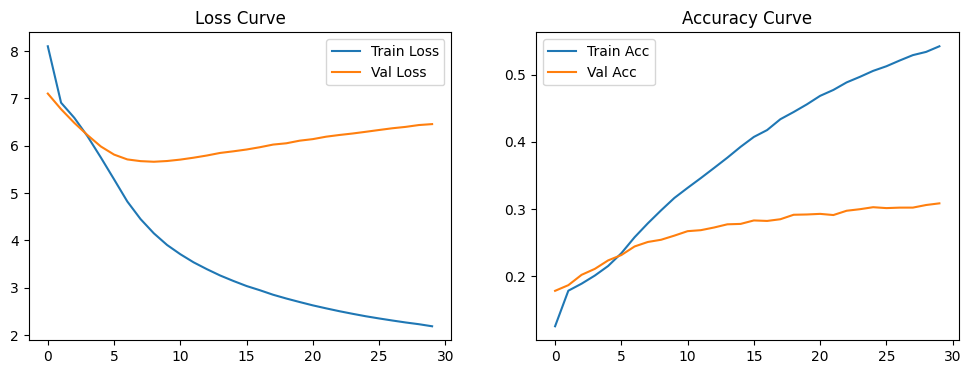

In [104]:
# 결과 그래프
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Accuracy Curve')
plt.legend()

plt.show()

# 4. Inference (토큰 생성)

In [105]:
def decoder_inference(model, sentence, tokenizer, max_token_len, temperature=1.0, mode="argmax", device='cpu'):
    START_TOKEN = tokenizer.bos_id()
    END_TOKEN = tokenizer.eos_id()
    MAX_LENGTH = max_token_len

    # 전처리
    sentence = preprocess_sentence(sentence)

    # 인코더 입력: [START] + 인코딩 + [END] -> 사용 안 함
    # # enc_input_ids = [START_TOKEN] + tokenizer.encode(sentence) + [END_TOKEN]
    # enc_input_ids = tokenizer.encode(sentence)
    # # 차원 확장: (batch_size=1, seq_len)
    # enc_input = torch.tensor([enc_input_ids], dtype=torch.long, device=device)

    # 디코더 입력(dec_input)을 START_TOKEN만 포함한 상태로 시작
    dec_input = torch.tensor([[START_TOKEN]], dtype=torch.long, device=device)

    model.eval()  # 모델 평가 모드
    with torch.no_grad():
        for i in range(MAX_LENGTH):
            # 모델 forward: (enc_input, dec_input) -> (batch_size=1, seq_len, vocab_size)
            logits = model(dec_input)

            # 마지막 타임스텝의 예측만 추출: shape (1, 1, vocab_size)
            # logits[:, -1, :] -> (1, vocab_size)
            last_step_logits = logits[:, -1, :] / temperature

            
            if mode == 'multinomial':
                # 수정 후: 확률 분포에 따라 샘플링 (Temperature 효과가 나타남)
                probs = torch.softmax(last_step_logits, dim=-1)
                predicted_id = torch.multinomial(probs, num_samples=1).squeeze(-1) # shape: (1,)
            else:
                # argmax로 가장 높은 확률의 토큰 선택 -> 순위가 안 바뀌면 무조건 똑같은 것만 나옴
                predicted_id = torch.argmax(last_step_logits, dim=-1)  # shape: (1,)            
            
            # 종료 토큰이면 중단
            if predicted_id.item() == END_TOKEN:
                break

            # 디코더 입력(dec_input)에 예측 토큰을 이어붙임
            predicted_id = predicted_id.unsqueeze(0)  # shape (1,1)
            dec_input = torch.cat([dec_input, predicted_id], dim=1)

    # 최종 시퀀스: dec_input: (1, seq_len)에서 (seq_len,)로
    output_sequence = dec_input.squeeze(0).tolist()  # e.g. [START_TOKEN, ..., 토큰들...]

    return output_sequence

In [106]:
def sentence_generation(model, sentence, tokenizer, max_token_len=MAX_TOKEN_LEN, temperature=1.0, mode="argmax", device='cpu'):
    # 디코더 인퍼런스 -> 예측된 토큰 시퀀스
    output_seq = decoder_inference(model, sentence, tokenizer, max_token_len, temperature=temperature, mode=mode, device=device)

    # 토크나이저로 디코딩 (패딩, START/END 토큰 등은 제외하거나 처리)
    # 여기서는 단순히 tokenizer.decode() 직접 호출
    predicted_sentence = tokenizer.decode(
        [token for token in output_seq if token < tokenizer.GetPieceSize()]
    )

    print("입력 :", sentence)
    print(f"출력 (T={temperature}):", predicted_sentence)
    return predicted_sentence

In [107]:
loaded_model = GPT1(vocab_size=VOCAB_SIZE, n_layers=N_LAYERS, max_token_len=MAX_TOKEN_LEN, 
                    emb_dim=EMB_DIM, n_heads=N_HEADS, ff_dim=FF_DIM, dropout=DROPOUT).to(device)

model_path = MODEL_PATH + "best_model.pt"
ckpt = torch.load(model_path, map_location=device, weights_only=False)
# ckpt = torch.load('best_transformer_model.pth', map_location=device, weights_only=False)
loaded_model.load_state_dict(ckpt['model'])

<All keys matched successfully>

In [108]:
ckpt['epoch']

9

In [109]:
# Temperature
# logit을 평탄화 시켜서 극단적으로 값이 치우치지 않게 해서 다양한 예측 결과 가능
T1 = 1.0
T2 = 1.2

In [ ]:
input_sentences = [
    '12시 땡!', # 학습데이터에 있는 문장
    '좋은 아침입니다',
    '날씨가 더워졌어', 
    '기분이 좋아지려면 뭘 해야 할까?'
]

In [113]:
for sentence in input_sentences:
    
    print("argmax 방식")
    answer1 = sentence_generation(loaded_model, sentence, sp_tokenizer, max_token_len=MAX_TOKEN_LEN, temperature=T1, device=device)
    answer2 = sentence_generation(loaded_model, sentence, sp_tokenizer, max_token_len=MAX_TOKEN_LEN, temperature=T2, device=device)
    print("multinomial 방식")
    answer3 = sentence_generation(loaded_model, sentence, sp_tokenizer, max_token_len=MAX_TOKEN_LEN, temperature=T1, mode='multinomial', device=device)
    answer4 = sentence_generation(loaded_model, sentence, sp_tokenizer, max_token_len=MAX_TOKEN_LEN, temperature=T2, mode='multinomial', device=device)
    print("-"*20)

argmax 방식
입력 : 12시 땡!
출력 (T=1.0): 나 좋아하는 애 피하는 방법 있어. 좋아하는 사람은 사람으로 잊혀지기도 해요.
입력 : 12시 땡!
출력 (T=1.2): 나 좋아하는 애 피하는 방법 있어. 좋아하는 사람은 사람으로 잊혀지기도 해요.
multinomial 방식
입력 : 12시 땡!
출력 (T=1.0): 복붙하다 힘들어 운동으로연다 많은 걸 말해주죠.
입력 : 12시 땡!
출력 (T=1.2): 여자가 운동계는 방법 말씀해보세요.
--------------------
argmax 방식
입력 : 좋은 아침입니다
출력 (T=1.0): 나 좋아하는 애 피하는 방법 있어. 좋아하는 사람은 사람으로 잊혀지기도 해요.
입력 : 좋은 아침입니다
출력 (T=1.2): 나 좋아하는 애 피하는 방법 있어. 좋아하는 사람은 사람으로 잊혀지기도 해요.
multinomial 방식
입력 : 좋은 아침입니다
출력 (T=1.0): 저금통기한 시간이 흐르하겠어요.
입력 : 좋은 아침입니다
출력 (T=1.2): 누군가를 두달 친구를인가 따뜻이 집착하는 중 힘들었겠어요.
--------------------
argmax 방식
입력 : 날씨가 더워졌어
출력 (T=1.0): 나 좋아하는 애 피하는 방법 있어. 좋아하는 사람은 사람으로 잊혀지기도 해요.
입력 : 날씨가 더워졌어
출력 (T=1.2): 나 좋아하는 애 피하는 방법 있어. 좋아하는 사람은 사람으로 잊혀지기도 해요.
multinomial 방식
입력 : 날씨가 더워졌어
출력 (T=1.0): 썸남이랑 짝남 연락해 보는게조심하세요? 수 있을까요.
입력 : 날씨가 더워졌어
출력 (T=1.2): 놀이 만났어 남자친구 후폭풍이 없지시지 선저 눈물 돌아오는 게 몸에는 좋을 것 같아요.
--------------------
argmax 방식
입력 : 기분이 좋아지려면 뭘 해야 할까?
출력 (T=1.0): 나 좋아하는 애 피하는 방법 있어. 좋아하는 사람은 사람으로 잊혀지기도 해요.
입력 : 기분이 좋아지려면 뭘 해야 할까?
출력 

Inference 결과 분석

- 모델이 똑같은 출력만 내뱉는 문제가 발생하였음  
- temperature 적용해서 logit을 평탄화 시켰지만, 확신을 갖고 계속 똑같은 결과를 내뱉음  
- argmax 기법으로는 순위가 가장 높은 결과가 계속 나오므로, multinomial을 적용했고 이전보다 다양한 출력을 내뱉지만 여전히 내용은 맞지 않음

# 회고

- 트랜스포머 구조 중 디코더만 활용하여 GPT1 구조를 구현해 볼 수 있었다.
- Positional embedding에 순서 index를 input으로 넣어줘야 한다는 것을 알게 되었다.
- inference 단계에서 모델이 어떤 입력을 넣어도 똑같은 문장(출력 문장 내 토큰은 다르게 내뱉음)을 내뱉어서 temperature, multinomial을 적용해보았다.   
&rarr; 근본적인 문제는 overfitting 때문인 것 같아서 overfitting을 해결할 수 있는 기법을 도입해야겠다.  
- 트랜스포머가 많이 활용되는 만큼, 이를 응용한 다른 모델도 찾아서 구현 연습을 해봐야겠다.